In [1]:
# Description: Plot Figure 1 (Maps with NWES segment locations, density at 200 m, and surface geostrophic circulation).
# Author:      André Palóczy

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from xarray import open_dataset
from copernicusmarine import open_dataset as open_dataset_copernicus
from cmocean.cm import dense, balance

from os.path import isfile
import cartopy.crs as ccrs
from cartopy.feature import LAND, RIVERS, BORDERS
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

In [3]:
proj = ccrs.PlateCarree()
def bmap(fig, ax, bb, proj=proj, xticks=None, yticks=None, dlon=2, dlat=2, land=LAND, coastlines=True):
    ax.set_extent(bb, proj)

    if land is not None:
        ax.add_feature(land, zorder=10, color="gray")

    ax.add_feature(BORDERS, zorder=11, color="black")
    # ax.add_feature(RIVERS, zorder=11, color="blue")

    if coastlines:
        ax.coastlines(zorder=11)

    if xticks is None:
        xticks = np.arange(bb[0], bb[1], dlon)
    if yticks is None:
        yticks = np.arange(bb[2], bb[3], dlat)

    gl = ax.gridlines(crs=proj, linewidth=0, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.left_labels = True
    gl.bottom_labels = True
    gl.right_labels = False
    gl.xlines = True
    gl.ylines = True
    gl.xlocator = mticker.FixedLocator(xticks)
    gl.ylocator = mticker.FixedLocator(yticks)
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {"size": 8, "color": "gray"}
    gl.ylabel_style = {"size": 8, "color": "gray"}

    return ax


def near(x, x0):
    return int(np.nanargmin(np.abs(x - x0)))


def near2(x, y, x0, y0):
    dr2 = (x - x0)**2 + (y - y0)**2
    return int(np.nanargmin(dr2))

## Define bounding box and segment names, set file paths.

In [4]:
xmin, xmax = -16.5, 10.5
ymin, ymax = 44, 63
iso_shelfbreak = 200
isobs = [iso_shelfbreak, 1000]

# Geography.
xtxt_segs = [-3.94, -8.18, -10.71, -9.565, -8.18, -3.31, 4.7, -7.24, 2.31, -12.91, 4.24, -3.71]
ytxt_segs = [46.91, 48.84, 51.21, 54.948, 58, 59.97, 57.63, 50.47, 56, 55.5, 59.41, 61.2]
txt_segs = ["AS", "CSS", "PSBS", "MS", "HS", "WSS", "NENSS", "Celtic\nSea", "North\nSea", "Rockall\nTrough", "NT", "Faroe-Shetland Channel"]
txt_rotations = [-30, -20, -75, 45, 30, 15, -20, 0, 0, 0, 0, 20]
txt_cols = ["r", "r", "r", "r", "r", "r", "r", "k", "k", "w", "w", "w"]

fwoa_dens = "../data/woa23/woa23D-annual.nc"
fbathymetry = "../data/srtm15p/SRTM15_V2.7.nc"
fmdt = "../data/cmems_mdt/mdt_cmems_2024_europe.nc"

## Download CMEMS MDT, or open it if file exists.

In [5]:
MDTid = "cmems_obs-sl_eur_phy-mdt_my_l4-0.0625deg_P20Y" # https://doi.org/10.48670/mds-00337
kw = dict(dataset_id=MDTid, minimum_longitude=xmin, maximum_longitude=xmax, minimum_latitude=ymin, maximum_latitude=ymax)

if isfile(fmdt):
    print("Opening CMEMS MDT.")
    dsmdt = open_dataset(fmdt).squeeze()
else:
    print("Downloading CMEMS MDT.")
    dsmdt = open_dataset_copernicus(**kw).squeeze()
    dsmdt.to_netcdf(fmdt)

Opening CMEMS MDT.


getfattr: Removing leading '/' from absolute path names


## Read MDT and surface geostrophic velocity fields.

In [6]:
xmdt, ymdt, mdt = dsmdt["longitude"].values, dsmdt["latitude"].values, dsmdt["mdt"]
u, v = dsmdt["u"], dsmdt["v"]
U = np.sqrt(u**2 + v**2)
err_U = np.sqrt(dsmdt["err_u"]**2 + dsmdt["err_v"]**2)
mskU = U>err_U
u = u.where(mskU)
v = v.where(mskU)

## Plot Figure 1.

getfattr: Removing leading '/' from absolute path names
getfattr: Removing leading '/' from absolute path names
/home/apaloczy/miniforge3/envs/xshelfNWES/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/apaloczy/miniforge3/envs/xshelfNWES/lib/python3.14/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


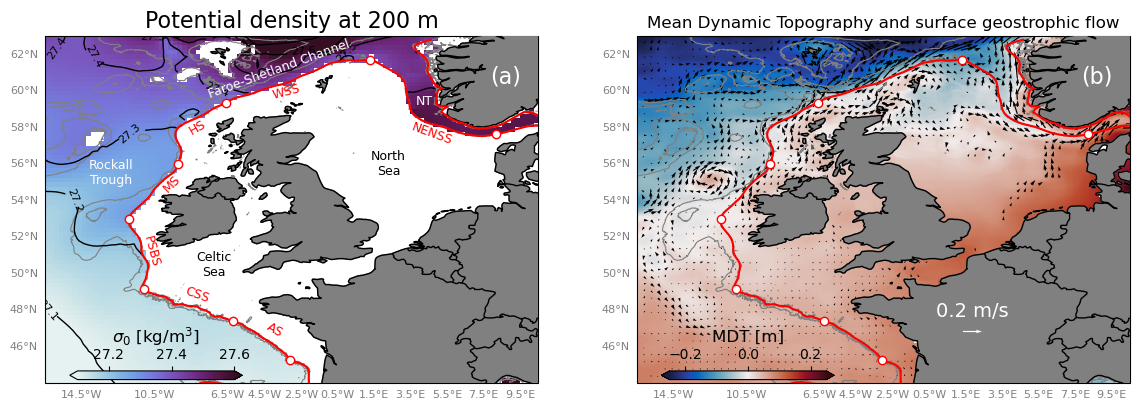

In [7]:
figsize = (14, 11)

dstopo = open_dataset(fbathymetry).sel(lon=slice(xmin, xmax), lat=slice(ymin, ymax))
ht = -dstopo["z"].values
xt, yt = np.meshgrid(dstopo["lon"].values, dstopo["lat"].values)

# Load smoothed isobath.
fisob = "../proc/isobath_200m.npz"
d = np.load(fisob)
xi, yi = d["xi_ext"], d["yi_ext"]

# Load Wei et al. (2024) sections.
xseg0, yseg0 = np.loadtxt("../proc/segment_latitudes_wei_etal2024.txt", unpack=True)
fseg = [near2(xi, yi, xseg0[i], yseg0[i]) for i in range(len(yseg0))]
xseg, yseg = xi[fseg], yi[fseg]

rho0 = open_dataset(fwoa_dens, decode_times=False)["rho0_an"].sel(depth=iso_shelfbreak) - 1000
x0, y0 = rho0["lon"].values, rho0["lat"].values
bb = (xmin, xmax, ymin, ymax)

# Plot maps with WOA23 density at 200 m and MDT/surface geostrophic circulation.
xtks = np.arange(xmin, xmax + 2, 2)
ytks = np.arange(ymin, ymax + 2, 2)

fig = plt.figure(figsize=figsize)
ax1 = fig.add_subplot(121, projection=proj)
ax2 = fig.add_subplot(122, projection=proj)
ax1, ax2 = bmap(fig, ax1, bb, xticks=xtks, yticks=ytks), bmap(fig, ax2, bb, xticks=xtks, yticks=ytks)
fig.subplots_adjust(hspace=0)
axs = [ax1, ax2]
_ = [ax.contour(xt, yt, ht, levels=isobs, colors="gray", linewidths=0.8) for ax in axs]
_ = [axi.plot(xi, yi, color="r", linewidth=1.5, zorder=20) for axi in axs]
_ = [axi.plot(xseg, yseg, linestyle="none", marker="o", ms=6, mfc="w", mec="r", zorder=21) for axi in axs]

vmi, vma = 27.1, 27.6

clevs = np.arange(vmi, vma + 0.1, 0.1)
cs1 = ax1.pcolormesh(x0, y0, rho0, vmin=vmi, vmax=vma, cmap=dense)
cc = ax1.contour(x0, y0, rho0, clevs, colors="k", linewidths=1); ax1.clabel(cc, fmt="%1.1f", fontsize=8, colors="k")

cs2 = ax2.pcolormesh(xmdt, ymdt, mdt, shading="auto", cmap=balance, vmin=-0.25, vmax=0.25)
q = ax2.quiver(xmdt, ymdt, u, v, regrid_shape=50)
# q = ax2.quiver(xmdt, ymdt, u, v, scale=0.5, regrid_shape=100)
umag = 0.2
ax2.quiverkey(q, 0.68, 0.15, umag, "%1.1f m/s"%umag, color="w", labelcolor="w", labelpos="N", coordinates="axes", fontproperties={"size": 14}, zorder=20)

cax1 = ax1.inset_axes([0.05, 0.01, 0.35, 0.025])
cb1 = fig.colorbar(cs1, cax=cax1, orientation="horizontal", extend="both")
cb1.ax.xaxis.set_ticks_position("top"); cb1.ax.xaxis.set_label_position("top")
cb1.set_label(r"$\sigma_0$ [kg/m$^3$]", fontsize=12)

cax2 = ax2.inset_axes([0.05, 0.01, 0.35, 0.025])
cb2 = fig.colorbar(cs2, cax=cax2, orientation="horizontal", extend="both")
cb2.ax.xaxis.set_ticks_position("top"); cb2.ax.xaxis.set_label_position("top")
cb2.set_label(r"MDT [m]", fontsize=12)

# Annotations.
for xt, yt, txt, rot, col in zip(xtxt_segs, ytxt_segs, txt_segs, txt_rotations, txt_cols):
    ax1.text(xt, yt, txt, rotation=rot, ha="center", va="center", fontsize=9, color=col, zorder=9)

ax1.text(8.7, 60.8, "(a)", ha="center", va="center", fontsize=16, color="w", zorder=11)
ax2.text(8.7, 60.8, "(b)", ha="center", va="center", fontsize=16, color="w", zorder=11)
ax1.set_title("Potential density at 200 m", fontsize=16, fontweight="normal")
ax2.set_title("Mean Dynamic Topography and surface geostrophic flow", fontsize=12, fontweight="normal");

In [8]:
fig.savefig("fig1.png", bbox_inches="tight", dpi=200)